## Step 1 — Ingest: Load Raw CSVs into Delta Tables

Source CSVs (`Games.csv`, `TeamStatisticsExtended.csv`) were uploaded via
**Catalog → Add Data → Upload files to DBFS**, then loaded into Delta tables
using the cell below. This only needs to run once — after the tables exist,
the rest of the notebook reads from Delta directly.

In [ ]:
# ── Run once: Load raw CSVs into Delta tables ──

games_raw = spark.read.csv(
    "dbfs:/FileStore/tables/Games.csv",
    header=True,
    inferSchema=True
)

stats_raw = spark.read.csv(
    "dbfs:/FileStore/tables/TeamStatisticsExtended.csv",
    header=True,
    inferSchema=True
)

games_raw.write.format("delta").mode("overwrite").saveAsTable(
    "nba_referee_analysis.referee_analysis.games"
)

stats_raw.write.format("delta").mode("overwrite").saveAsTable(
    "nba_referee_analysis.referee_analysis.team_statistics_extended"
)

print("Raw tables loaded:")
print("   nba_referee_analysis.referee_analysis.games")
print("   nba_referee_analysis.referee_analysis.team_statistics_extended")

## Step 2 Read Delta Tables for Analysis

In [0]:
# Read the Delta tables
games = spark.table(
    "nba_referee_analysis.referee_analysis.games"
).toPandas()

stats = spark.table(
    "nba_referee_analysis.referee_analysis.team_statistics_extended"
).toPandas()

print(f"Games rows: {len(games):,}")
print(f"Stats rows: {len(stats):,}")

Games rows: 73,276
Stats rows: 79,718


In [0]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# ── Season type mapping ──────────────────────────────────
SEASON_TYPE_MAP = {
    "Regular Season":     "Regular Season",
    "Emirates NBA Cup":   "Regular Season",
    "NBA Cup":            "Regular Season",
    "Playoffs":           "Playoffs",
    "Play-in Tournament": "Playoffs",
}

games["season_type"] = games["gameType"].map(SEASON_TYPE_MAP)
games = games[games["season_type"].notna()].copy()

stats["season_type"] = stats["gameType"].map(SEASON_TYPE_MAP)
stats = stats[stats["season_type"].notna()].copy()

# ── Build per-game foul + result table ───────────────────
winning_team = (stats[stats["win"] == 1]
                [["gameId","foulsPersonal"]]
                .rename(columns={"foulsPersonal":"winner_fouls"}))

losing_team  = (stats[stats["win"] == 0]
                [["gameId","foulsPersonal"]]
                .rename(columns={"foulsPersonal":"loser_fouls"}))

home_result  = (stats[stats["home"] == 1]
                [["gameId","win"]]
                .rename(columns={"win":"home_won"}))

foul_table = (winning_team
              .merge(losing_team, on="gameId")
              .merge(home_result, on="gameId"))

foul_table["total_fouls"]     = foul_table["winner_fouls"] + foul_table["loser_fouls"]
foul_table["winner_foul_pct"] = (foul_table["winner_fouls"] / foul_table["total_fouls"] * 100).round(1)
foul_table["loser_foul_pct"]  = (foul_table["loser_fouls"]  / foul_table["total_fouls"] * 100).round(1)

# ── Explode officials — one row per (game, referee) ──────
games["officials_list"] = games["officials"].dropna().str.split(r",\s*")
ref_rows = (games[["gameId","season_type","officials_list"]]
            .dropna(subset=["officials_list"])
            .explode("officials_list")
            .rename(columns={"officials_list":"referee"}))
ref_rows["referee"] = ref_rows["referee"].str.strip()
ref_rows = ref_rows[ref_rows["referee"] != ""]
ref_rows = ref_rows.merge(foul_table, on="gameId", how="inner")

# ── Aggregate per referee × season type ──────────────────
def summarize(group):
    total = len(group)
    hw    = group["home_won"].sum()
    return pd.Series({
        "games_officiated":         total,
        "home_team_wins":           int(hw),
        "away_team_wins":           int(total - hw),
        "home_win_pct":             round(hw / total * 100, 1),
        "away_win_pct":             round((total - hw) / total * 100, 1),
        "avg_winner_fouls":         round(group["winner_fouls"].mean(), 1),
        "avg_loser_fouls":          round(group["loser_fouls"].mean(), 1),
        "avg_total_fouls_per_game": round(group["total_fouls"].mean(), 1),
        "avg_winner_foul_pct":      round(group["winner_foul_pct"].mean(), 1),
        "avg_loser_foul_pct":       round(group["loser_foul_pct"].mean(), 1),
    })

agg = (ref_rows
       .groupby(["referee","season_type"])
       .apply(summarize, include_groups=False)
       .reset_index())

# ── Pivot so Regular Season & Playoffs are side by side ──
metrics = ["games_officiated","home_team_wins","away_team_wins",
           "home_win_pct","away_win_pct","avg_winner_fouls",
           "avg_loser_fouls","avg_total_fouls_per_game",
           "avg_winner_foul_pct","avg_loser_foul_pct"]

pivot = agg.pivot(index="referee", columns="season_type", values=metrics)
pivot.columns = [f"{s}_{m}" for m, s in pivot.columns]
pivot = pivot.reset_index()

for s in ["Regular Season", "Playoffs"]:
    col = f"{s}_games_officiated"
    if col in pivot.columns:
        pivot[col] = pivot[col].fillna(0).astype(int)

pivot["total_games_officiated"] = (
    pivot.get("Regular Season_games_officiated", 0) +
    pivot.get("Playoffs_games_officiated", 0)
)
pivot = pivot.sort_values("total_games_officiated", ascending=False).reset_index(drop=True)

print(f"Analysis complete — {len(pivot)} referees")
pivot.head(10)

Analysis complete 82 referees


,referee,Playoffs_games_officiated,Regular Season_games_officiated,Playoffs_home_team_wins,Regular Season_home_team_wins,Playoffs_away_team_wins,Regular Season_away_team_wins,Playoffs_home_win_pct,Regular Season_home_win_pct,Playoffs_away_win_pct,Regular Season_away_win_pct,Playoffs_avg_winner_fouls,Regular Season_avg_winner_fouls,Playoffs_avg_loser_fouls,Regular Season_avg_loser_fouls,Playoffs_avg_total_fouls_per_game,Regular Season_avg_total_fouls_per_game,Playoffs_avg_winner_foul_pct,Regular Season_avg_winner_foul_pct,Playoffs_avg_loser_foul_pct,Regular Season_avg_loser_foul_pct,total_games_officiated
0,Josh Tiven,14,64,8.0,32.0,6.0,32.0,57.1,50.0,42.9,50.0,20.4,19.4,21.2,19.1,41.6,38.4,49.2,50.5,50.8,49.5,78
1,Ray Acosta,11,67,7.0,35.0,4.0,32.0,63.6,52.2,36.4,47.8,22.4,19.1,23.2,19.8,45.5,38.9,49.2,49.0,50.8,51.0,78
2,Mitchell Ervin,12,64,6.0,39.0,6.0,25.0,50.0,60.9,50.0,39.1,22.3,20.0,22.4,21.2,44.8,41.1,49.8,48.7,50.2,51.3,76
3,Marc Davis,14,62,7.0,31.0,7.0,31.0,50.0,50.0,50.0,50.0,20.8,19.5,23.1,19.5,43.9,39.1,47.7,50.2,52.3,49.8,76
4,James Williams,12,64,6.0,39.0,6.0,25.0,50.0,60.9,50.0,39.1,20.7,18.8,20.2,19.4,40.9,38.2,50.4,49.1,49.6,50.9,76
5,Scott Foster,13,62,10.0,33.0,3.0,29.0,76.9,53.2,23.1,46.8,22.5,20.2,23.2,21.1,45.8,41.3,49.2,48.9,50.8,51.1,75
6,Gediminas Petraitis,10,65,4.0,32.0,6.0,33.0,40.0,49.2,60.0,50.8,20.5,20.1,22.1,20.2,42.6,40.3,48.4,49.9,51.6,50.1,75
7,Nick Buchert,11,63,8.0,30.0,3.0,33.0,72.7,47.6,27.3,52.4,20.7,20.2,22.4,20.6,43.1,40.8,48.1,49.7,51.9,50.3,74
8,Justin Van Duyne,9,65,5.0,35.0,4.0,30.0,55.6,53.8,44.4,46.2,24.1,19.5,23.6,19.7,47.7,39.2,50.7,50.0,49.3,50.0,74
9,James Capers,13,61,7.0,40.0,6.0,21.0,53.8,65.6,46.2,34.4,22.8,18.9,23.9,20.0,46.8,38.9,48.9,48.5,51.1,51.5,74


In [0]:
# Clean column names for Delta compatibility
pivot.columns = (
    pivot.columns.astype(str)
        .str.replace(" ", "_", regex=False)
        .str.replace("%", "pct", regex=False)
        .str.replace("/", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace("(", "", regex=False)
        .str.replace(")", "", regex=False)
)

# Convert Pandas DataFrame to Spark DataFrame
result_spark = spark.createDataFrame(pivot)

# Save as a Delta table
(result_spark
    .write
    .format("delta")
    .mode("overwrite")
    .saveAsTable(
        "nba_referee_analysis.referee_analysis.referee_summary"
    )
)

print("Saved as Delta table")
print("Catalog : nba_referee_analysis")
print("Schema  : referee_analysis")
print("Table   : referee_summary")

# Optional validation
spark.table(
    "nba_referee_analysis.referee_analysis.referee_summary"
).show(5)

Saved as Delta table
Catalog : nba_referee_analysis
Schema  : referee_analysis
Table   : referee_summary
+--------------+-------------------------+-------------------------------+-----------------------+-----------------------------+-----------------------+-----------------------------+---------------------+---------------------------+---------------------+---------------------------+-------------------------+-------------------------------+------------------------+------------------------------+---------------------------------+---------------------------------------+----------------------------+----------------------------------+---------------------------+---------------------------------+----------------------+
|       referee|Playoffs_games_officiated|Regular_Season_games_officiated|Playoffs_home_team_wins|Regular_Season_home_team_wins|Playoffs_away_team_wins|Regular_Season_away_team_wins|Playoffs_home_win_pct|Regular_Season_home_win_pct|Playoffs_away_win_pct|Regular_Season_away_w

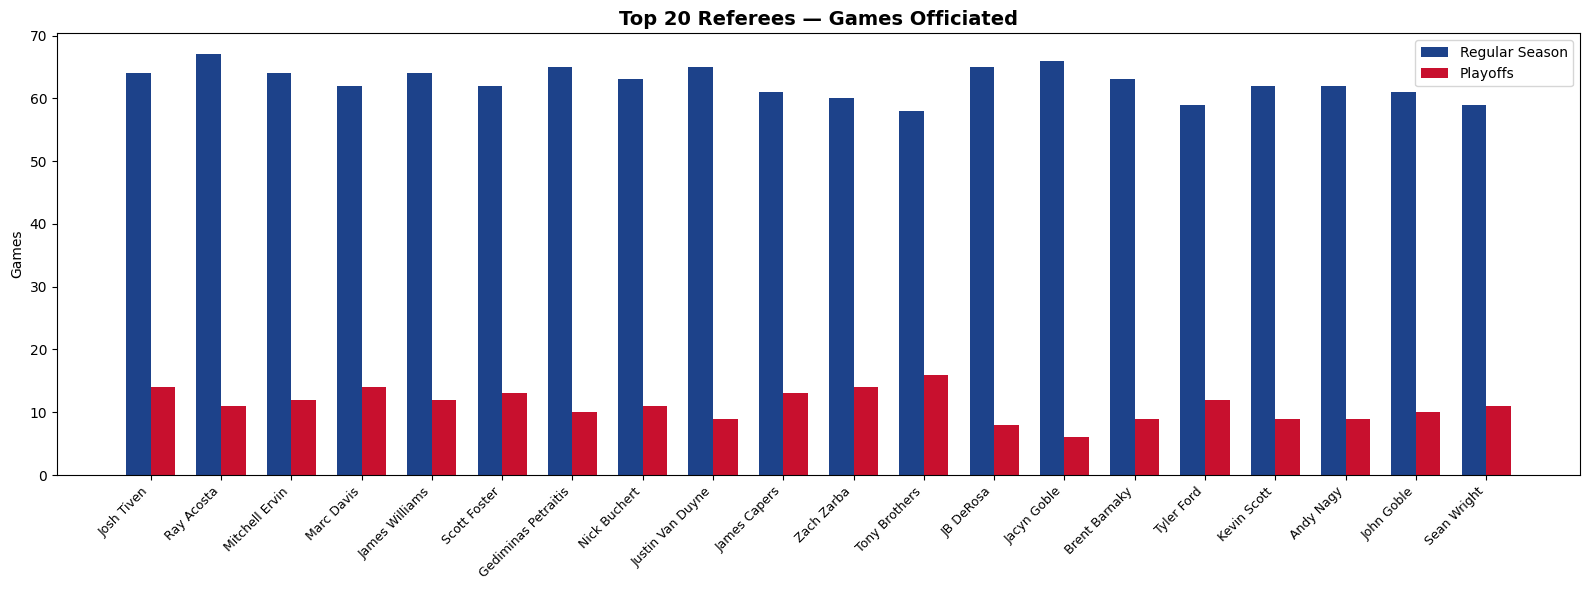

In [0]:
import base64
import io

import matplotlib.pyplot as plt

top20 = pivot.head(20).copy()
x = range(len(top20))
w = 0.35

fig, ax = plt.subplots(figsize=(16, 6))

ax.bar(
    [i - w/2 for i in x],
    top20["Regular_Season_games_officiated"],
    w,
    label="Regular Season",
    color="#1d428a"
)

ax.bar(
    [i + w/2 for i in x],
    top20["Playoffs_games_officiated"],
    w,
    label="Playoffs",
    color="#c8102e"
)

ax.set_xticks(list(x))
ax.set_xticklabels(top20["referee"], rotation=45, ha="right", fontsize=9)
ax.set_title("Top 20 Referees — Games Officiated", fontsize=14, fontweight="bold")
ax.set_ylabel("Games")
ax.legend()

plt.tight_layout()

# ── Save to buffer and render download button ──
buf = io.BytesIO()
plt.savefig(buf, format="png", dpi=150, bbox_inches="tight")
buf.seek(0)
b64 = base64.b64encode(buf.read()).decode()
plt.show()

displayHTML(f'''
  <a href="data:image/png;base64,{b64}"
     download="games_officiated.png"
     style="display:inline-block; margin-top:10px; padding:8px 16px;
            background:#1d428a; color:white; border-radius:4px;
            text-decoration:none; font-family:sans-serif;">
    Download chart: games_officiated.png
  </a>
''')


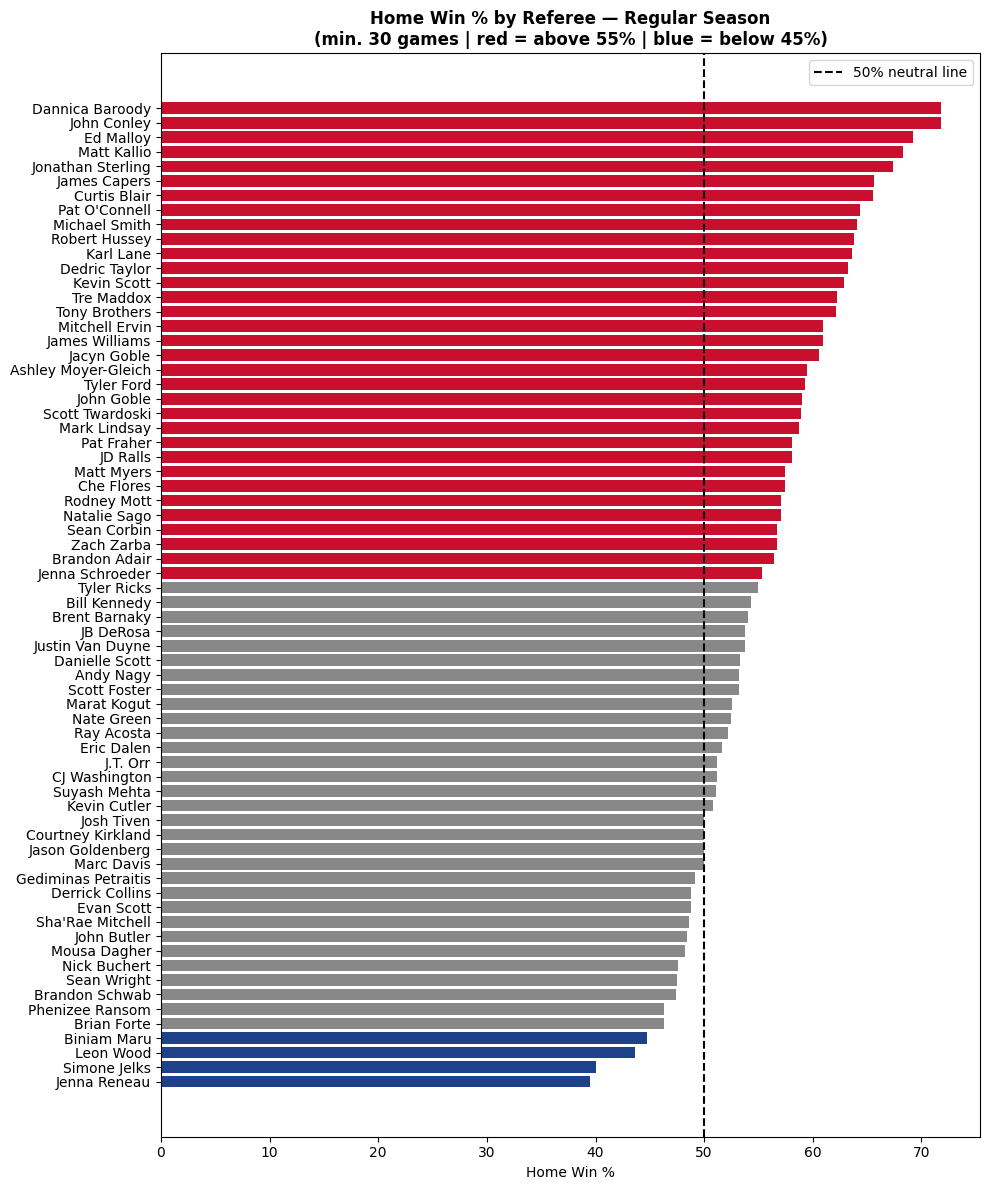

In [0]:
import base64
import io

# Only refs with 30+ Regular Season games for statistical reliability
rs = pivot[pivot["Regular_Season_games_officiated"] >= 30].copy()

rs = rs.sort_values(
    "Regular_Season_home_win_pct",
    ascending=True
)

colors = [
    "#c8102e" if v > 55
    else "#1d428a" if v < 45
    else "#888888"
    for v in rs["Regular_Season_home_win_pct"]
]

fig, ax = plt.subplots(figsize=(10, 12))

ax.barh(
    rs["referee"],
    rs["Regular_Season_home_win_pct"],
    color=colors
)

ax.axvline(
    50,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="50% neutral line"
)

ax.set_title(
    "Home Win % by Referee — Regular Season\n(min. 30 games | red = above 55% | blue = below 45%)",
    fontsize=12,
    fontweight="bold"
)

ax.set_xlabel("Home Win %")
ax.legend()

plt.tight_layout()

# ── Save to buffer and render download button ──
buf = io.BytesIO()
plt.savefig(buf, format="png", dpi=150, bbox_inches="tight")
buf.seek(0)
b64 = base64.b64encode(buf.read()).decode()
plt.show()

displayHTML(f'''
  <a href="data:image/png;base64,{b64}"
     download="home_win_pct.png"
     style="display:inline-block; margin-top:10px; padding:8px 16px;
            background:#1d428a; color:white; border-radius:4px;
            text-decoration:none; font-family:sans-serif;">
    Download chart: home_win_pct.png
  </a>
''')


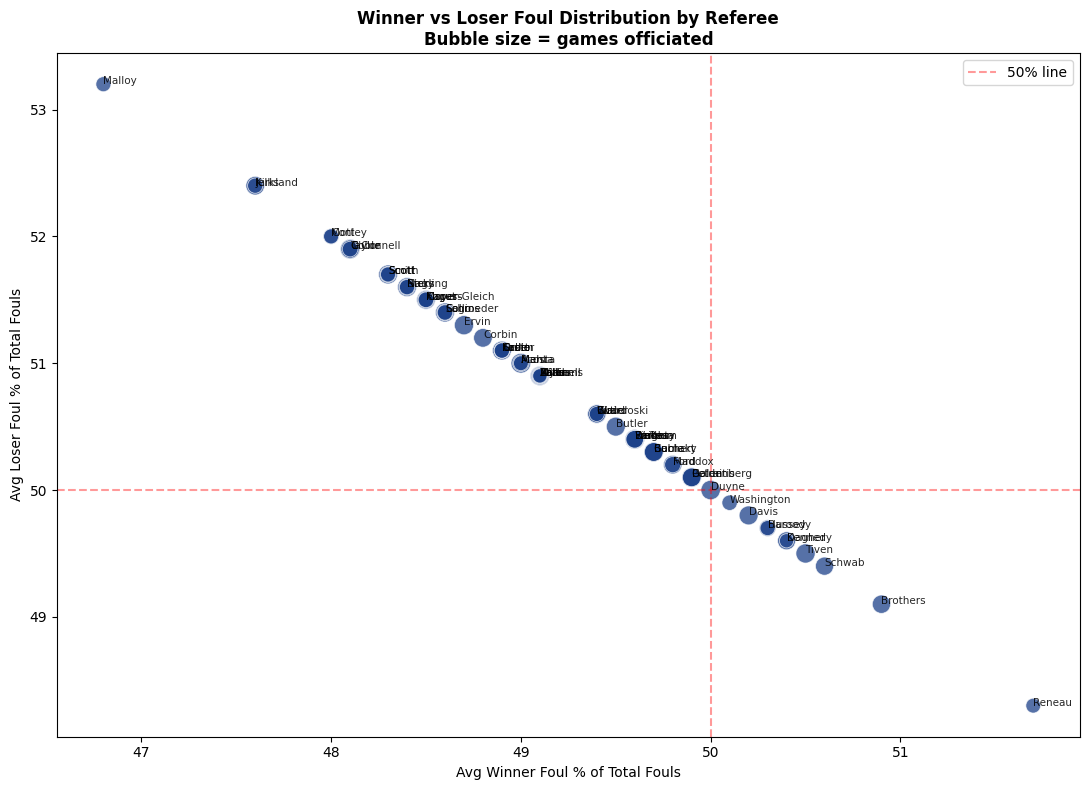

In [0]:
import base64
import io

rs = pivot[pivot["Regular_Season_games_officiated"] >= 20].copy()

fig, ax = plt.subplots(figsize=(11, 8))

ax.scatter(
    rs["Regular_Season_avg_winner_foul_pct"],
    rs["Regular_Season_avg_loser_foul_pct"],
    s=rs["Regular_Season_games_officiated"] * 3,
    alpha=0.75,
    color="#1d428a",
    edgecolors="white",
    linewidth=0.6
)

for _, row in rs.iterrows():
    ax.annotate(
        row["referee"].split()[-1],
        (
            row["Regular_Season_avg_winner_foul_pct"],
            row["Regular_Season_avg_loser_foul_pct"]
        ),
        fontsize=7.5,
        alpha=0.85
    )

ax.axvline(
    50,
    color="red",
    linestyle="--",
    alpha=0.4,
    label="50% line"
)

ax.axhline(
    50,
    color="red",
    linestyle="--",
    alpha=0.4
)

ax.set_xlabel("Avg Winner Foul % of Total Fouls")
ax.set_ylabel("Avg Loser Foul % of Total Fouls")

ax.set_title(
    "Winner vs Loser Foul Distribution by Referee\nBubble size = games officiated",
    fontsize=12,
    fontweight="bold"
)

ax.legend()

plt.tight_layout()

# ── Save to buffer and render download button ──
buf = io.BytesIO()
plt.savefig(buf, format="png", dpi=150, bbox_inches="tight")
buf.seek(0)
b64 = base64.b64encode(buf.read()).decode()
plt.show()

displayHTML(f'''
  <a href="data:image/png;base64,{b64}"
     download="foul_scatter.png"
     style="display:inline-block; margin-top:10px; padding:8px 16px;
            background:#1d428a; color:white; border-radius:4px;
            text-decoration:none; font-family:sans-serif;">
    Download chart: foul_scatter.png
  </a>
''')
